In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [73]:
P = 100000 # total population
V0 =0 # vaccinated
I0 = 1 # infected
beta =0.3
gamma =0.2
days =200
mu =0.0 # death rate

def Gillespie_model(P,I0,beta,gamma, days,mu):

    S=P-I0-V0
    I =I0
    R=V0
    t=0
    D=0

    t_=[]
    s_=[]
    i_=[]
    r_=[]
    d_=[]
    R0 = beta/gamma
    HT = 1-1/R0 # heard immunity threshold
    
    while t< days and I>0:
        rate_infection = S*(beta*I/P) # no. suceptible*prob. of infection
        rate_recovery = gamma * I
        death_rate = mu*I
        total_rate = rate_infection + rate_recovery + death_rate
        dt = np.random.exponential(1 / total_rate) # events have exponential distribution
        t = t+dt
        
        infection_prob = rate_infection/total_rate
        recovery_prob = rate_recovery/total_rate
        
        

        if total_rate ==0:
            break
        RN = np.random.random()
        if RN < infection_prob:
            #infection
            S =S-1  
            I =I+1
        #recovery
        elif RN < infection_prob + recovery_prob:
            I =I-1
            R =R+1
        else: #deaths
            I=I-1
            D=D+1
        t_.append(t)
        s_.append(S)
        i_.append(I)
        r_.append(R)
        d_.append(D)

    return t_,s_,i_,r_,d_
        

In [74]:
np.random.seed(42)
a,b,c,d,e =Gillespie_model(100000,10,0.3,0.2, 200,0)


### 1.0 Simulation - with no Intervention
#### Total population: 100,000
#### Initial infections : 10
#### vaccinations: 0

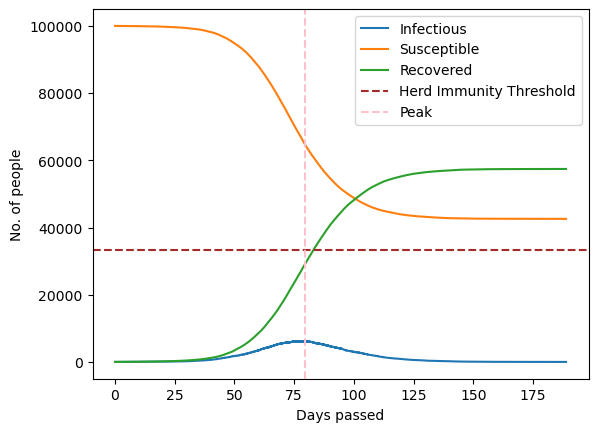

In [75]:
R0 = beta/gamma
HT = (1-1/R0)*P # heard immunity threshold
plt.plot(a,c,label='Infectious')
plt.plot(a,b,label='Susceptible')
plt.plot(a,d,label='Recovered')

plt.axhline(y=HT, color='brown', linestyle='--',label='Herd Immunity Threshold')
peak =a[np.argmax(c)]
plt.axvline(x=peak, color='pink', linestyle='--',label='Peak')
plt.xlabel("Days passed")
plt.ylabel("No. of people")
plt.legend()
plt.show()


In [5]:
## Repeat the simulation for mutiple times 
# first define the initial values
##########################################
P = 100000 # total population
V0 =0 # vaccinated
I0 = 10 # infected
beta =0.3 #transmission rate
gamma =0.2 # recovery rate
days =200
n_runs = 200
#########################################

def multi_run(P,V0,I0,beta,gamma,days,n_runs):
    T_=[]
    S_=[]
    I_=[]
    R_=[]
    R0 = beta/gamma
    HT = 1-1/R0 # heard immunity threshold
    np.random.seed(42)
    #fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(14, 5))
    for i in range(0,n_runs):
        t_,s_,i_,r_ = Gillespie_model(P,I0,beta,gamma, days)
        T_.append(t_)
        S_.append(s_)
        I_.append(i_)
        R_.append(r_)
        #print(i_)
        # ax1.plot(t_,s_,label='S', color='green')
        # ax2.plot(t_,i_,label='I', color='blue')
        # ax3.plot(t_,r_,label='R', color='Magenta')
        #print(np.mean(s_))
    return T_,S_,I_,R_
    

In [15]:
## no intervention
T_,S_,I_,R_ =multi_run(100000,0,I0=10,beta=0.3,gamma=0.2,days=200,n_runs=200)


In [24]:
import pandas as pd
from scipy import stats

def goodness_of_fit(data, f, args): ##Kolmogorov-Smirnov test 
    ks_stat, p_value = stats.kstest(data, f, args =args)
    IsgoodFit='no'
    if p_value > 0.05:
        IsgoodFit='yes'   
    return round(ks_stat,3),round(p_value,3),IsgoodFit

def confidence_int(data,mu, sigma,Z):
    n=len(data)
    fitted_mean = np.exp(mu + sigma**2 / 2)
    se_mu    = sigma / np.sqrt(n)
    se_sigma = sigma / np.sqrt(2 * n)
    z=Z
    lower = np.exp((mu - z * se_mu) + (sigma - z * se_sigma)**2 / 2)
    upper = np.exp((mu + z * se_mu) + (sigma + z * se_sigma)**2 / 2)
    return lower,upper


    

def get_stat_peaktime(T_,S_,I_,R_):
    min_s=[np.min(lst) for lst in S_] #not infected
    max_i=[np.max(lst) for lst in I_] #max infected
    max_index =  [np.argmax(lst) for lst in I_]

    peak_time =[]
    for i in range(len(T_)):
        peak_time.append(T_[i][max_index[i]])
    
    df = pd.DataFrame()
    df['not_infected'] = min_s
    df['max_infected'] = max_i
    df['Recovered'] = [np.max(lst) for lst in R_]
    df['Peaktime'] = peak_time
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    ax1.hist(df['Peaktime'],bins=25,label='Peak time')
    ax1.set_xlabel('Day')
    ax1.set_ylabel('Counts/Bin')
    ax1.set_title('Peaktime')
    #ax1.legend()
    ax1.grid(True, alpha=0.3)
    ###fitting peaktime data
    df1 = df[df['Peaktime']>20]

    data = df1['Peaktime'].dropna().values
    shape, loc, scale = stats.lognorm.fit(data, floc=0)
    mu    = np.log(scale)  
    sigma = shape 
    mean = stats.lognorm.mean(shape, loc, scale)
    std = stats.lognorm.std(shape, loc, scale)

 
    ci_lower,ci_upper =confidence_int(data,mu, sigma,1.96)
    x1 = np.linspace(data.min(), data.max(), 200)
    pdf = stats.lognorm.pdf(x1, shape, loc, scale)

    ax2.hist(df['Peaktime'], bins=50, density=True, alpha=0.6,
        color='#6366f1', label='Data')
    ax2.plot(x1, pdf, color='#ef4444', lw=2.5, label='Log-normal fit- Peak time')
    ax2.set_xlabel('Day')
    ax2.set_ylabel('Density')
    ax2.set_title('Log-normal Fit -Peak time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    textstr = f'$\mu={mean:.2f}$\n$\sigma={std:.2f}$'
    plt.text(0.05, 0.15, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='bottom', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    plt.show()

    ks_stat, p_value,value =gooness_of_fit(data,'lognorm', args=(shape, loc, scale))
    #print(ks_stat,p_value,value)
     
    return df,data,mean,std,ci_lower,ci_upper,shape,loc,scale


In [59]:
def get_stat_maxInfections(T_,S_,I_,R_,df,Z):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    ax1.hist(df['max_infected'],bins=25,label='')
    ax1.set_xlabel('# of people infected')
    ax1.set_ylabel('Counts/Bin')
    ax1.set_title('# infected at the Peak')
    #ax1.legend()
    ax1.grid(True, alpha=0.3)
    df1 = df[df['max_infected']>20]
    data = df1['max_infected'].dropna().values
    #mu, sigma = stats.norm.fit(data)
    shape, loc, scale = stats.lognorm.fit(data, floc=0)
    mu    = np.log(scale)  
    sigma = shape 
    mean = stats.lognorm.mean(shape, loc, scale)
    std = stats.lognorm.std(shape, loc, scale)
    
    n = len(data)
    # std_error  = sigma / np.sqrt(n)
    # lower = mu - Z*std_error
    # upper = mu + Z*std_error

    fitted_mean = np.exp(mu + sigma**2 / 2)
    se_mu    = sigma / np.sqrt(n)
    se_sigma = sigma / np.sqrt(2 * n)
    z=Z
    lower = np.exp((mu - z * se_mu) + (sigma - z * se_sigma)**2 / 2)
    upper = np.exp((mu + z * se_mu) + (sigma + z * se_sigma)**2 / 2)

    ks_stat, p_value = stats.kstest(data, 'lognorm', args=(shape, loc,scale))
    ax2.hist(data, bins=25, density=True, alpha=0.6,
        color='#6366f1', label='Data')

    x   = np.linspace(data.min(), data.max(), 200)
    #pdf = stats.norm.pdf(x, mu, sigma)
    pdf = stats.lognorm.pdf(x, shape, loc, scale)
    ax2.plot(x, pdf, color='#ef4444', lw=2.5, label=f'fit\nμ={mu:.2f}, σ={sigma:.2f}')
    plt.tight_layout()
    plt.show()
    print(f'Goodness of fit results (Kolmogorov-Smirnov test) : k_stat={k_stat:.2f}, p_value={p_value:.2f}')
    return mean,std,lower,upper,ks_stat,p_value
    

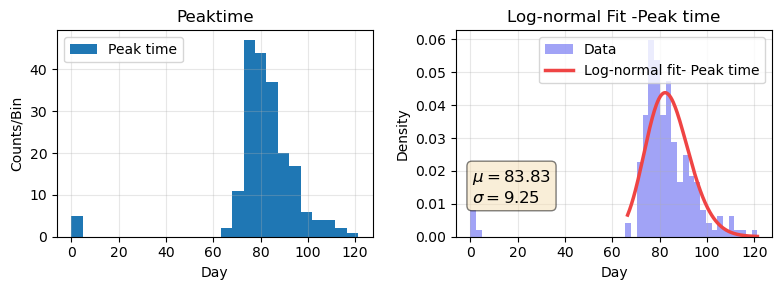

Mean days to peak of the pandemic : 83.83
Std. Deviation : 9.25
95% confidence interval for the mean : [82.45,85.24]
Goodness of fit results (Kolmogorov-Smirnov test) : k_stat=0.09, p_value=0.07, Good fit:yes


In [62]:
df_no_intervention,data,mean,std,ci_lower,ci_upper,shape,loc,scale = get_stat_peaktime(T_,S_,I_,R_)
k_stat,p_value, IsGoodFit = goodness_of_fit(data, 'lognorm', args=(shape,loc,scale))
print(f'Mean days to peak of the pandemic : {mean:.2f}')
print(f'Std. Deviation : {std:.2f}')
print(f'95% confidence interval for the mean : [{ci_lower:.2f},{ci_upper:.2f}]')
print(f'Goodness of fit results (Kolmogorov-Smirnov test) : k_stat={k_stat:.2f}, p_value={p_value:.2f}, Good fit:{IsGoodFit}')

6358.23308371449 211.10188539038464


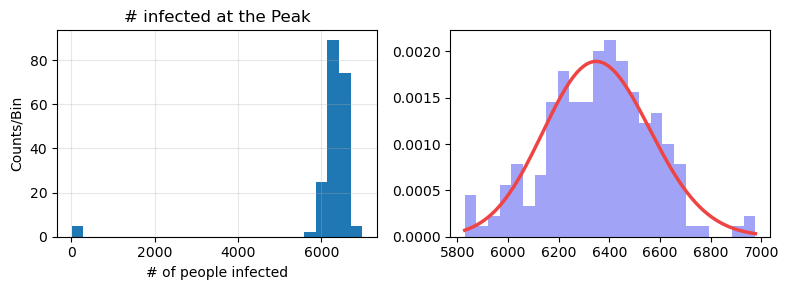

Goodness of fit results (Kolmogorov-Smirnov test) : k_stat=0.09, p_value=0.63
Mean of maximun infections during the pandemic : 6358.23
Std. Deviation : 211.10
95% confidence interval for the mean : [6328.02,6388.66]
Goodness of fit results (Kolmogorov-Smirnov test) : k_stat=0.09, p_value=0.63


In [64]:
mean,sigma,lower,upper,ks_stat,p_value = get_stat_maxInfections(T_,S_,I_,R_,df_no_intervention,1.96)
print(f'Mean of maximun infections during the pandemic : {mean:.2f}')
print(f'Std. Deviation : {sigma:.2f}')
print(f'95% confidence interval for the mean : [{lower:.2f},{upper:.2f}]')
print(f'Goodness of fit results (Kolmogorov-Smirnov test) : k_stat={k_stat:.2f}, p_value={p_value:.2f}')

In [66]:
df_no_intervention

,not_infected,max_infected,Recovered,Peaktime
0,42577,6190,57423,79.674779
1,42091,6421,57909,75.614514
2,41578,6464,58422,79.281215
3,42587,6501,57399,107.120828
4,41398,6541,58599,77.547801
...,...,...,...,...
195,42520,6383,57480,81.691923
196,41646,6428,58354,83.809308
197,41862,6425,58130,95.076479
198,42552,6022,57448,88.695577


### 1.1 Simuation with deaths
#### death rate = 0.005

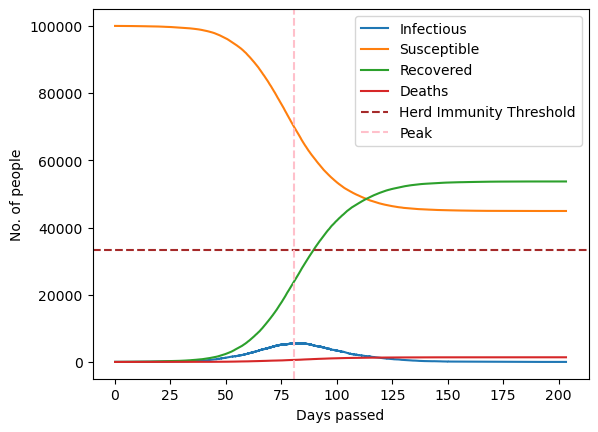

In [78]:
np.random.seed(42)
a,b,c,d,e =Gillespie_model(100000,10,0.3,0.2, 200,0.005)
R0 = beta/gamma
HT = (1-1/R0)*P # heard immunity threshold
plt.plot(a,c,label='Infectious')
plt.plot(a,b,label='Susceptible')
plt.plot(a,d,label='Recovered')
plt.plot(a,e,label='Deaths')
plt.axhline(y=HT, color='brown', linestyle='--',label='Herd Immunity Threshold')
peak =a[np.argmax(c)]
plt.axvline(x=peak, color='pink', linestyle='--',label='Peak')
plt.xlabel("Days passed")
plt.ylabel("No. of people")
plt.legend()
plt.show()

In [8]:
#https://pmc.ncbi.nlm.nih.gov/articles/PMC8119989/
#https://pmc.ncbi.nlm.nih.gov/articles/PMC8063609/
#https://onlinelibrary.wiley.com/doi/full/10.1002/mma.7965